In [5]:
import numpy as np
import pandas as pd
from EMDPM.utils import solve_system
from EMDPM.em_transformer_rework import EM
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from sklearn.model_selection import GroupKFold, GridSearchCV


In [6]:
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")
n_biomarkers = 10

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

print("after drop na", df.shape)
subj_counts = df['subj_id'].value_counts()
num_unique = (subj_counts == 1).sum()
print("one time subj_id:", num_unique)

longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])
print("after drop dupes", df.shape)

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# As a list:
print(biomarker_names)  # List[str]

print("nans in X:", np.isnan(X_obs).sum())
print("infs in X:", np.isinf(X_obs).sum())


## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)
print(K.shape, type(K))

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

np.save("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/K_68", K, allow_pickle=True)
t_max = 40
step = 0.001
print("X.size: ", X_obs.shape)

ids = df["subj_id"].to_numpy()
dt = df["time"].to_numpy()/12 # convert to years
#cog = df["MCATOT"].values#,"TD_score","PIGD_score"]].values
cog = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
nhy = df["NHY"].to_numpy()

df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')  # handles any remaining invalid entries

nsd = df["NSD_STAGE"].to_numpy()


print("nans in cog:", np.isnan(cog).sum())
print("infs in cog:", np.isinf(cog).sum())


original size: (880, 250)
after drop na (868, 250)
one time subj_id: 227
after drop dupes (504, 250)
['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg', 'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg', 'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg', 'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg', 'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg', 'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg', 'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg', 'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_

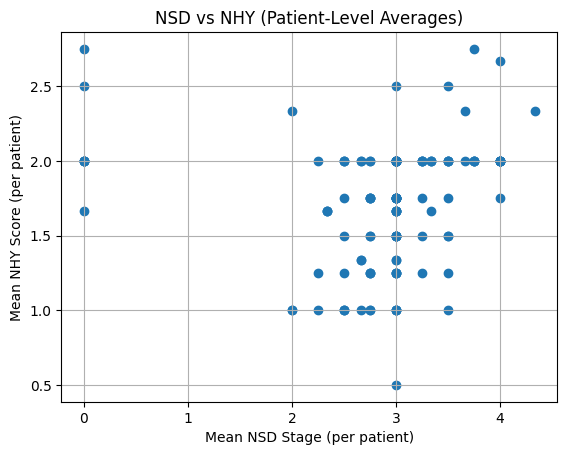

In [7]:
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')  # handles any remaining invalid entries

patient_df = df.copy()
patient_df["NHY"] = nhy  # add NHY array to df
grouped = patient_df.groupby("subj_id")[["NSD_STAGE", "NHY"]].mean().dropna()

plt.scatter(grouped["NSD_STAGE"], grouped["NHY"])
plt.xlabel("Mean NSD Stage (per patient)")
plt.ylabel("Mean NHY Score (per patient)")
plt.title("NSD vs NHY (Patient-Level Averages)")
plt.grid(True)
plt.show()

nsd = df["NSD_STAGE"].to_numpy()


count    504.000000
mean       0.002763
std        0.012933
min       -0.075794
25%       -0.003324
50%        0.003218
75%        0.010403
max        0.041529
Name: avg_slope, dtype: float64


/home/dsemchin/miniconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/dsemchin/miniconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/dsemchin/miniconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


(array([ 7., 15., 18.,  6.,  8., 15., 41., 29.,  5.,  2.]),
 array([ 0.        ,  3.87854543,  7.75709087, 11.6356363 , 15.51418174,
        19.39272717, 23.27127261, 27.14981804, 31.02836347, 34.90690891,
        38.78545434]),
 <BarContainer object of 10 artists>)

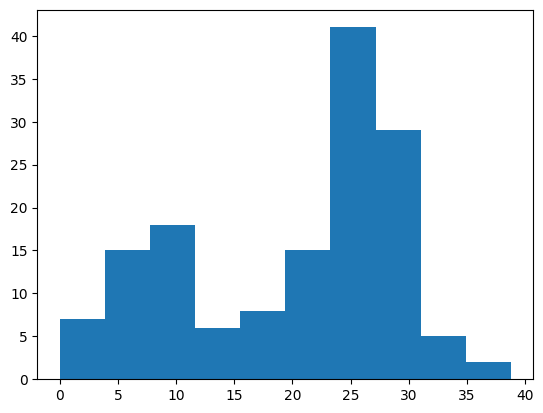

In [8]:
def compute_patient_avg_slope(X, dt, ids):
    unique_ids = np.unique(ids)
    pid_to_slope = {}
    
    for pid in unique_ids:
        mask = (ids == pid)
        t = dt[mask].reshape(-1,1)
        Xi = X[mask]                       
        if Xi.shape[0] < 2:
            pid_to_slope[pid] = 0.0
            continue
        
        slopes = []
        for j in range(Xi.shape[1]):
            y = Xi[:, j]
            # simple linear fit: biomarker_j = a * dt + b
            a = np.linalg.lstsq(np.hstack([t, np.ones_like(t)]), y, rcond=None)[0][0]
            slopes.append(a)
        pid_to_slope[pid] = np.mean(slopes)
        
    return pid_to_slope

def prepare_glm_data(df, X, dt, ids, cog_df):
    df_proc = df.copy()
    df_proc['dt'] = dt
    df_proc['id'] = ids
        
    df_proc[['MCATOT','PIGD_score','TD_score']] = cog_df[['MCATOT','PIGD_score','TD_score']]
    pid_to_slope = compute_patient_avg_slope(X, dt, ids)
    df_proc['avg_slope'] = df_proc['id'].map(pid_to_slope)
    
    print(df_proc['avg_slope'].describe())
    
    return df_proc

def init_beta_mixedlm(df_proc, t_max):
    # Use dt_scaled as response; random intercept on 'id'
    model = smf.mixedlm("dt ~ MCATOT + PIGD_score + TD_score + avg_slope",
                         data=df_proc,
                         groups=df_proc["id"],
                         re_formula="1")
    result = model.fit()
    
    # intercepts
    rand_eff = result.random_effects  # dict pid->{'Group': val}
    pid_to_beta = {pid: eff["Group"] * t_max for pid, eff in rand_eff.items()}
    return pid_to_beta

df_proc = prepare_glm_data(df=df, X=X_obs, dt=dt, ids=ids, cog_df=df[["MCATOT","PIGD_score","TD_score"]])

pid_to_beta = init_beta_mixedlm(df_proc, t_max=t_max)
unique_ids = np.unique(ids)
beta_init = np.array([pid_to_beta.get(pid, 0.0) for pid in unique_ids])

initial_beta = (beta_init + np.abs(min(beta_init)))*1e9
plt.hist(initial_beta)

Spearman ρ = -0.311, p = 0.000135
Pearson r = -0.319, p = 8.7e-05


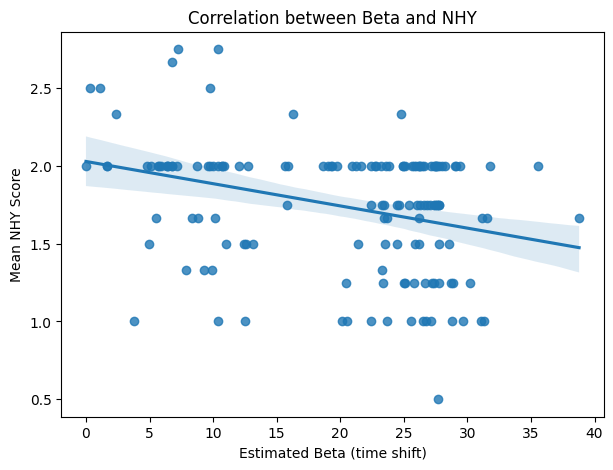

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

# Assume these are already defined:
# - nhy: full array with NHY per visit
# - ids: corresponding patient IDs per visit
# - beta: final beta array per unique patient (in order of unique_ids)

# Step 1: Compute mean NHY per patient
unique_ids = np.unique(ids)
pid_to_nhy = {pid: np.mean(nhy[ids == pid]) for pid in unique_ids}

# Step 2: Align NHY with beta values
nhy_vals = []
beta_vals = []

for i, pid in enumerate(unique_ids):
    if pid in pid_to_nhy:
        nhy_vals.append(pid_to_nhy[pid])
        beta_vals.append(initial_beta[i])

nhy_vals = np.array(nhy_vals)
beta_vals = np.array(beta_vals)

# Step 3: Plot
plt.figure(figsize=(7, 5))
sns.regplot(x=beta_vals, y=nhy_vals)
plt.xlabel("Estimated Beta (time shift)")
plt.ylabel("Mean NHY Score")
plt.title("Correlation between Beta and NHY")

# Step 4: Print correlation
rho, p = spearmanr(beta_vals, nhy_vals)
r, p_pearson = pearsonr(beta_vals, nhy_vals)

print(f"Spearman ρ = {rho:.3f}, p = {p:.3g}")
print(f"Pearson r = {r:.3f}, p = {p_pearson:.3g}")


In [10]:
from sklearn.model_selection import train_test_split

def create_patient_list(X_obs, ids, dt, cog, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
            "nhy": nhy[mask],
            "nsd": nsd[mask,]
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

X = create_patient_list(X_obs, ids, dt, cog, initial_beta)
X_train, X_val = train_test_split(X, test_size=0.2, random_state=75)

np.save("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_train_68biom_wNSD", X_train, allow_pickle=True)
np.save("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_val_68biom_wNSD", X_val, allow_pickle=True)

In [11]:
from sklearn.metrics import make_scorer

model = EM(K=K)
# param_grid = {
#     "lambda_f": [0.9, 0.95, 1.0, 1.1],
#     "lambda_cog": [0.01, 0.025, 0.05],
#     "lambda_scalar": [0.0, 0.01, 0.02],
#     "jac_toggle": [True],
#     "max_iter": [15],
#     "t_max": [40],
#     "epsilon": [1e-1],
# }

param_grid = {
    "lambda_f": [0.5, 0.7, 0.95],
    "lambda_cog": [0.01, 0.025, 0.05],
    "lambda_scalar": [0.0, 0.01, 0.05],
    "jac_toggle": [True],
    "max_iter": [20],
    "t_max": [40],
    "epsilon": [1e-1],
}

param_grid_reduced = {
    "lambda_f": [0.1, 0.3, 0.7],
    "lambda_cog": [0.1, 0.3],
    "lambda_scalar": [0.01, 0.1, 0.3],
    "jac_toggle": [True],
    "max_iter": [20],
}

groups_train = [p["id"] for p in X_train]

grid = GridSearchCV(
    estimator=EM(K=K),
    param_grid=param_grid,
    cv=GroupKFold(n_splits=3),
    scoring=None,
    n_jobs=15
)
grid.fit(X=X_train, y=None, groups=groups_train)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)


  0%|          | 0/20 [00:00<?, ?it/s]capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.

  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import make_scorer

model = EM(K=K)
# param_grid = {
#     "lambda_f": [0.9, 0.95, 1.0, 1.1],
#     "lambda_cog": [0.01, 0.025, 0.05],
#     "lambda_scalar": [0.0, 0.01, 0.02],
#     "jac_toggle": [True],
#     "max_iter": [15],
#     "t_max": [40],
#     "epsilon": [1e-1],
# }

param_grid = {
    "lambda_f": [0.5, 0.7, 0.95],
    "lambda_cog": [0.01, 0.025, 0.05],
    "lambda_scalar": [0.0, 0.01, 0.05],
    "jac_toggle": [True],
    "max_iter": [20],
    "t_max": [40],
    "epsilon": [1e-1],
}

param_grid_reduced = {
    "lambda_f": [0.1, 0.3, 0.7],
    "lambda_cog": [0.1, 0.3],
    "lambda_scalar": [0.01, 0.1, 0.3],
    "jac_toggle": [True],
    "max_iter": [20],
}

groups_train = [p["id"] for p in X_train]

grid = GridSearchCV(
    estimator=EM(K=K),
    param_grid=param_grid,
    cv=GroupKFold(n_splits=3),
    scoring=None,
    n_jobs=15
)
grid.fit(X=X_train, y=None, groups=groups_train)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)


 70%|███████   | 14/20 [00:15<00:05,  1.17it/s]

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2713134260794D+02   r2 =  0.1711467299402D-14
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2713134260794D+02   r2 =  0.1711467299402D-14
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2713134260794D+02   r2 =  0.1159154249508D-14
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2713134260794D+02   r2 =  0.1159154249508D-14
 lsoda--  warning..internal t (=r1) 

/home/dsemchin/Progression_models_simulations/EMDPM/utils.py:25: RuntimeWarning: overflow encountered in matmul
  return (np.eye(K.shape[0]) - np.diag(x)) @ ((scalar_K * K @ x) + f) # TODO: double check position of f wrt parenthesis
/home/dsemchin/Progression_models_simulations/EMDPM/utils.py:25: RuntimeWarning: invalid value encountered in matmul
  return (np.eye(K.shape[0]) - np.diag(x)) @ ((scalar_K * K @ x) + f) # TODO: double check position of f wrt parenthesis
/home/dsemchin/miniconda3/lib/python3.12/site-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
Estimating beta values: 100%|██████████| 39/39 [00:00<00:00, 250.24it/s]
/home/dsemchin/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
1 fits failed out of a total of 81.
The score on these train-test partitions for these parameters will be set to nan.
If these failures ar

Best score: -17.994886254107097
Best params: {'epsilon': 0.1, 'jac_toggle': True, 'lambda_cog': 0.05, 'lambda_f': 0.7, 'lambda_scalar': 0.0, 'max_iter': 20, 't_max': 40}


40.0


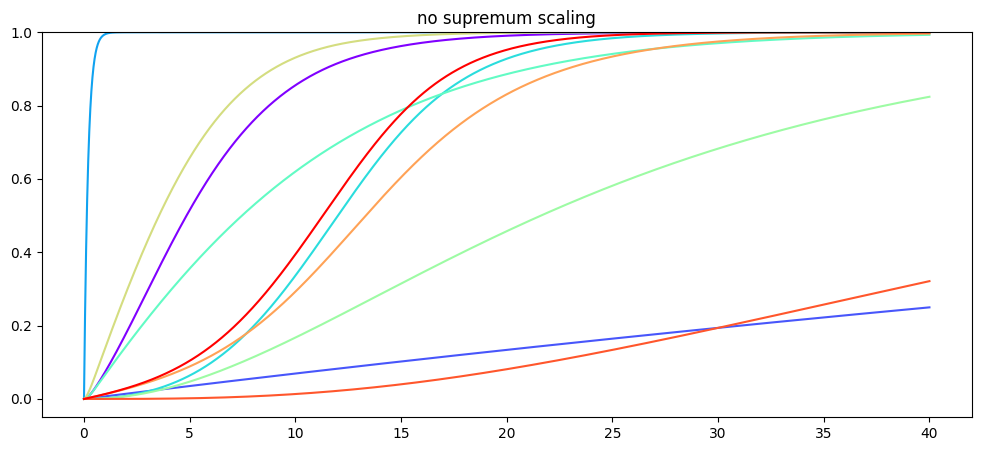

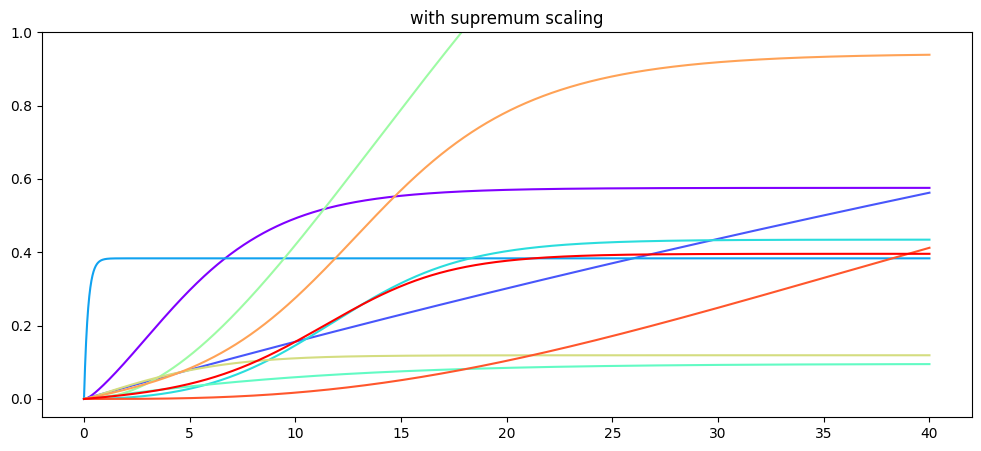

initial theta:
f:  [0.021 0.015 0.066 0.068 0.093 0.075 0.093 0.095 0.087 0.001]
s:  [1.299 2.487 0.166 0.503 2.96  2.982 2.482 2.546 1.264 2.035]
s_k:  0.9870000000000001
final theta:
f:  [0.    0.007 5.234 0.    0.    0.    0.032 0.012 0.    0.012]
s:  [0.576 2.252 0.383 0.434 0.096 2.511 0.119 0.942 1.283 0.396]
s_k:  0.8593288622070615

BETA SUMMARY:
beta initial:  [11.302 22.229 10.152  5.849 17.598 16.867 19.372 15.584 16.76  19.693]
beta final:  [18.812 17.838 22.78  18.862 20.618 18.759 23.028 19.149 19.403 22.3  ]


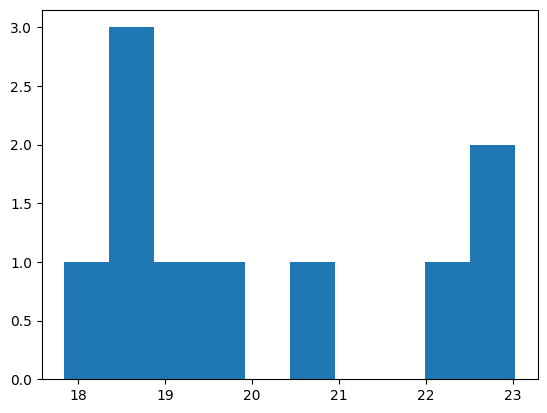

Best score: -17.994886254107097
Best params: {'epsilon': 0.1, 'jac_toggle': True, 'lambda_cog': 0.05, 'lambda_f': 0.7, 'lambda_scalar': 0.0, 'max_iter': 20, 't_max': 40}


In [ ]:


best_model = grid.best_estimator_

t_span = best_model.t_span
print(t_span[-1])
theta_history = best_model.theta_history
beta_history = best_model.beta_history
lse_history = best_model.lse_history

initial_theta = theta_history[:,0]
initial_x0 = np.zeros(n_biomarkers)
initial_f = initial_theta[0:n_biomarkers]
initial_s = initial_theta[n_biomarkers:2*n_biomarkers]
initial_scalar_K = initial_theta[-1]
#initial_model = solve_system(initial_x0, initial_f, K, t_span, initial_scalar_K)

# final params
final_theta = theta_history[:,-1]
final_x0 = np.zeros(n_biomarkers)
final_f = final_theta[0:n_biomarkers]
final_s = final_theta[n_biomarkers:2*n_biomarkers]
final_scalar_K = final_theta[-1]
final_model = solve_system(final_x0, final_f, K, t_span, final_scalar_K)

plt.figure(figsize=(12,5))
colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))
for b in range(n_biomarkers):
    plt.plot(t_span, final_model[b], color = colors[b])
    plt.ylim(-0.05,1)
plt.title('no supremum scaling')
plt.show()

plt.figure(figsize=(12,5))
colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))
for b in range(n_biomarkers):
    plt.plot(t_span, final_model[b] * final_s[:,None][b], color = colors[b])
    plt.ylim(-0.05,1)
plt.title('with supremum scaling')
plt.show()

print("initial theta:")
print("f: ", np.round(initial_theta[:n_biomarkers], 3)[0:10])
print("s: ", np.round(initial_theta[n_biomarkers:2*n_biomarkers], 3)[0:10])
print("s_k: ", initial_theta[-1])

print("final theta:")
print("f: ", np.round(final_theta[:n_biomarkers], 3)[0:10])
print("s: ", np.round(final_theta[n_biomarkers:2*n_biomarkers], 3)[0:10])
print("s_k: ", final_theta[-1])

## Beta comparison:
print("\nBETA SUMMARY:")
print("beta initial: ", np.round(beta_history[0:10, 0], 3))
print("beta final: ", np.round(beta_history[0:10, -1], 3))

plt.figure()
plt.hist(beta_history[0:10, -1])
plt.show()

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

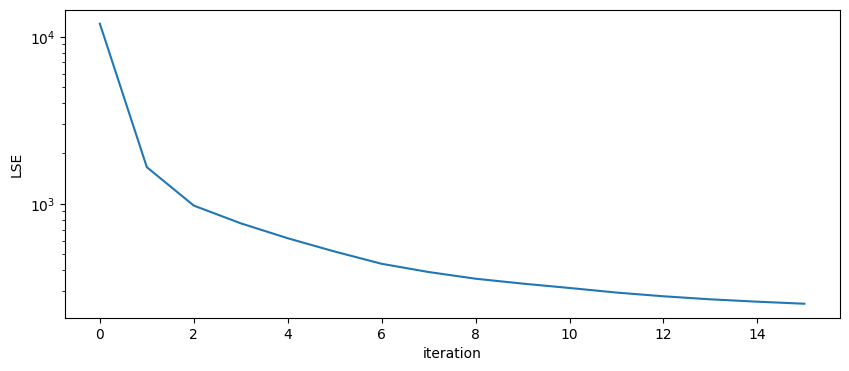

252.23797214624125


In [ ]:
plot_lse(lse_history)
print(lse_history[-1])
# plt.figure()
# plt.plot(lse_history[1:-1])
# plt.yscale('log')
# plt.show()

In [ ]:
def unpack_patient_list(patient_list):
    X_obs = []
    dt = []
    ids = []
    cog = []
    nhy = []
    for patient in patient_list:
        n_visits = patient["dt"].shape[0]
        pid = patient["id"]
        X_obs.append(patient["X_obs"])
        dt.append(patient["dt"])
        ids.append(np.full(n_visits, pid))
        cog.append(patient["cog"])
        nhy.append(patient["nhy"])
    return (
        np.vstack(X_obs),
        np.concatenate(dt),
        np.concatenate(ids),
        np.vstack(cog),
        np.concatenate(nhy),
    )

X_obs_val, dt_val, ids_val, cog_val, nhy_val = unpack_patient_list(X_val)

best_model = grid.best_estimator_
beta_val = best_model.transform(X_val)

theta = best_model.theta_history[:, -1]
n_biomarkers = X_obs_val.shape[1]
f = theta[:n_biomarkers]
s = theta[n_biomarkers:2 * n_biomarkers]
scalar_K = theta[-1]
final_model = solve_system(np.zeros(n_biomarkers), f, best_model.K, best_model.t_span, scalar_K)

Estimating beta values: 100%|██████████| 30/30 [00:00<00:00, 166.19it/s]


40.0


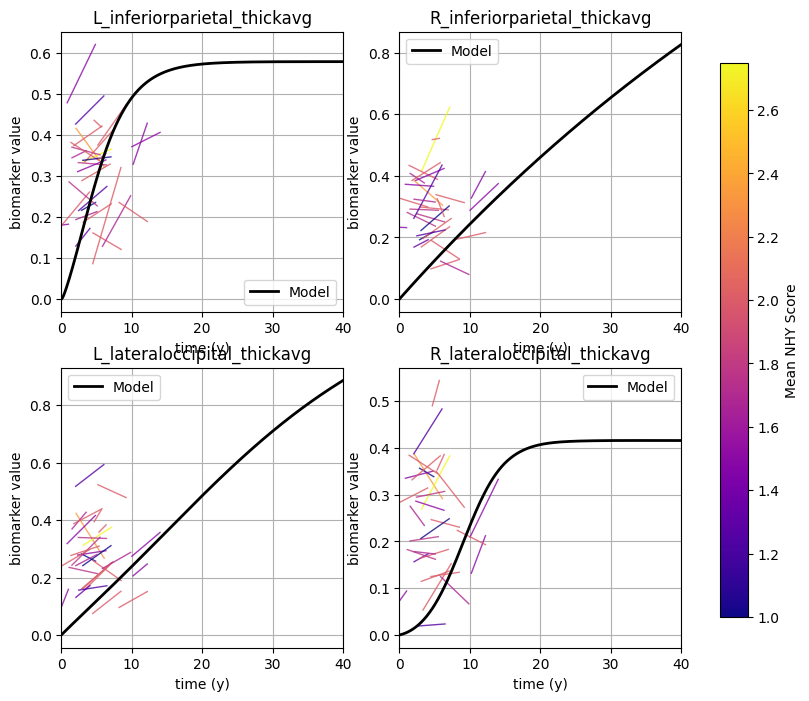

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import math
import matplotlib.cm as cm
import matplotlib.colors as colors

def plot_all_patient_regression_lines_grid_nhy(X, dt, ids, beta, t_span, nhy, model=None,
                                               biomarker_indices=None, biomarker_labels=None,
                                               max_lines=500, t_max=40):
    """
    Plot regression lines per patient for each selected biomarker on a grid of subplots.
    Each line is color-coded by the patient's mean NHY score.
    """
    if biomarker_indices is None:
        biomarker_indices = list(range(X.shape[1]))

    unique_ids = np.unique(ids)
    pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    # Compute mean NHY score per patient
    mean_nhy = {}
    for pid in unique_ids:
        nhy_i = nhy[ids == pid]
        mean_nhy[pid] = np.mean(nhy_i) if len(nhy_i) > 0 else np.nan

    # Colormap setup
    cmap = cm.plasma  # or viridis, inferno, etc.
    nhy_vals = np.array(list(mean_nhy.values()))
    norm = colors.Normalize(vmin=np.nanmin(nhy_vals), vmax=np.nanmax(nhy_vals))

    n_plots = len(biomarker_indices)
    n_cols = math.ceil(np.sqrt(n_plots))
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes = axes.flatten()

    for plot_idx, j in enumerate(biomarker_indices):
        ax = axes[plot_idx]
        title = biomarker_labels[j] if biomarker_labels else f"biomarker {j}"
        ax.set_title(f"{title}")
        ax.set_xlabel("time (y)")
        ax.set_ylabel("biomarker value")

        line_count = 0
        for pid in unique_ids:
            if line_count >= max_lines:
                break
            mask = (ids == pid)
            if np.sum(mask) < 2:
                continue

            X_i = X[mask, j]
            dt_i = dt[mask]
            beta_i = beta[pid_to_index[pid]]
            t_ij = dt_i + beta_i

            nhy_mean = mean_nhy[pid]
            if np.isnan(nhy_mean):
                continue
            line_color = cmap(norm(nhy_mean))

            model_i = LinearRegression().fit(t_ij.reshape(-1, 1), X_i)
            t_fit = np.linspace(t_ij.min(), t_ij.max(), 20)
            x_fit = model_i.predict(t_fit.reshape(-1, 1))

            ax.plot(t_fit, x_fit, color=line_color, alpha=0.8, linewidth=1)
            line_count += 1

        # Plot model-predicted trajectory
        if model is not None:
            ax.plot(t_span, model[j], color='black', linewidth=2, label="Model")
            ax.legend()

        ax.grid(True)
        ax.set_xlim(0, t_max)

    # Remove unused axes
    for k in range(n_plots, len(axes)):
        fig.delaxes(axes[k])

    # Add colorbar for NHY scale
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='vertical', shrink=0.9)
    cbar.set_label("Mean NHY Score")

    plt.show()
    
print(t_span[-1])
    
plot_all_patient_regression_lines_grid_nhy(
    X=X_obs_val,
    dt=dt_val,
    ids=ids_val,
    beta=beta_val,
    t_span=best_model.t_span,
    nhy=nhy_val,
    model=final_model * s[:, None],
    biomarker_indices=[0, 1, 8, 9],
    biomarker_labels=small_region_set,
    max_lines=500,
    t_max=best_model.t_span[-1]
)


/tmp/ipykernel_9077/1676804426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")


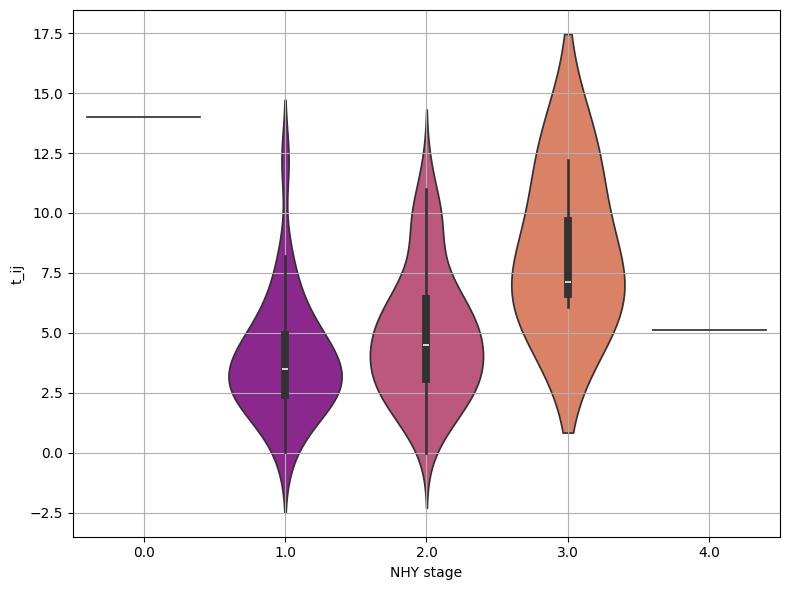

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_violin_nhy_vs_tij(dt, ids, beta, nhy):
    unique_ids = np.unique(ids)
    pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}
    t_ij = np.array([dt_i + beta[pid_to_index[pid]] for dt_i, pid in zip(dt, ids)])

    df = pd.DataFrame({
        "t_ij": t_ij,
        "NHY": nhy
    })

    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")
    plt.xlabel("NHY stage")
    plt.ylabel("t_ij")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_violin_nhy_vs_tij(dt=dt_val, ids=ids_val, beta=beta_val, nhy=nhy_val)


2


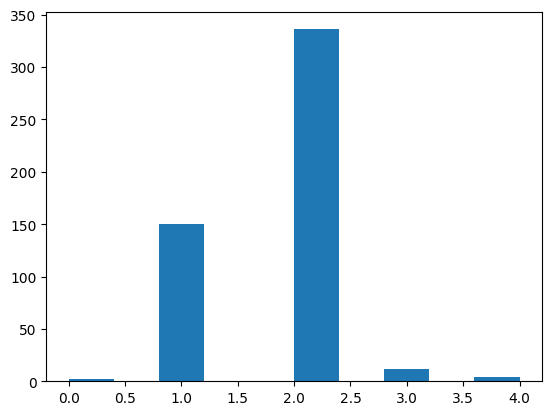

In [ ]:
plt.hist(nhy)
print(sum(nhy==0))

/tmp/ipykernel_9077/730019268.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")


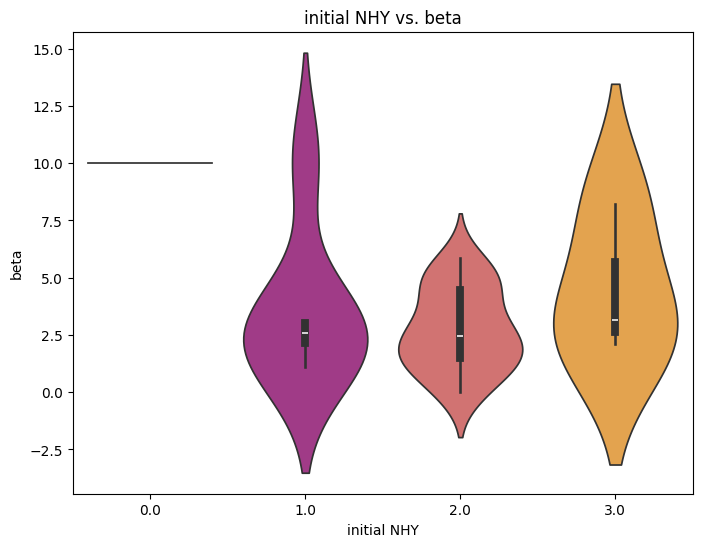

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_violin_nhy_vs_beta(ids, dt, nhy, beta):
    unique_ids = np.unique(ids)
    pair = []

    pid_to_beta = {pid: beta[i] for i, pid in enumerate(unique_ids)}

    for pid in unique_ids:
        mask = (ids == pid)
        dt_i = dt[mask]
        nhy_i = nhy[mask]
        idx_min_dt = np.argmax(dt_i)
        nhy_first = nhy_i[idx_min_dt]
        beta_i = pid_to_beta[pid]

        pair.append({"NHY": nhy_first, "beta": beta_i})

    df = pd.DataFrame(pair)

    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")
    plt.title("initial NHY vs. beta")
    plt.xlabel("initial NHY")
    plt.ylabel("beta")
    plt.show()

plot_violin_nhy_vs_beta(dt=dt_val, ids=ids_val, beta=beta_val, nhy=nhy_val)